# Chemistry Application

We consider the problem of densoising the Ramachandran plot of a given protein, which consists of noisy measurements of pairs of adjacent dihedral angles along the backbone of the protein. We consider the protein 6X8J and use publicly-available data from the Protein Data Bank (PDB).

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt

import Bio.PDB
from Bio.PDB.vectors import calc_dihedral, calc_angle
# from Bio import BiopythonWarning
# import warnings
# warnings.simplefilter('ignore', BiopythonWarning)

from geomstats.geometry.hypersphere import Hypersphere
from geomstats.geometry.product_manifold import ProductManifold

INFO: Using numpy backend


In [2]:
plt.rcParams.update({'font.size': 12,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

## Setting up

In [3]:
file = '6x8j.pdb1'

parser = Bio.PDB.PDBParser()
structure = parser.get_structure('protein', file)
polypeptide = Bio.PDB.PPBuilder().build_peptides(structure[0])

phi = []
psi = []

for strand in polypeptide:
    phipsi = strand.get_phi_psi_list()
    for point in phipsi:
        try:
            phi_point = point[0] * 1.
            psi_point = point[1] * 1.
            phi.append(phi_point)
            psi.append(psi_point)
        except TypeError:
            pass
    
X_phi, X_psi = np.asarray(phi), np.asarray(psi)
X = np.asarray([[np.cos(phi),np.sin(phi)],
                [np.cos(psi),np.sin(psi)]]).T

/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 3826.
  warnings.warn(
/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 3845.
  warnings.warn(
/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 3855.
  warnings.warn(
/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 3864.
  warnings.warn(


In [4]:
mean_b_factor = 0.
count = 0
for model in structure:
    for chain in model:
        for residue in chain:
            for atom in residue:
                count += 1
                mean_b_factor += atom.get_bfactor()

mean_b_factor /= count
sigma2 = np.arctan(np.sqrt(mean_b_factor/(8*np.pi**2))/1.5)**2
sigma2

0.261030240583988

In [5]:
circle = Hypersphere(dim=1)
torus = ProductManifold([circle, circle])

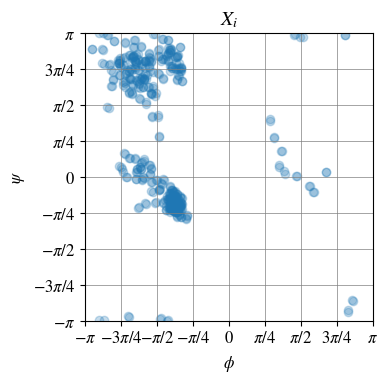

In [6]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111)

ax.scatter(X_phi, X_psi, color='C0', alpha=0.25)
ax.grid(True, color='gray', lw=0.5)
ax.axis('square')
ax.set_title('$X_i$')

radian_ticks = [i * np.pi/4 for i in range(-4,5)]
radian_ticklabels = ['$-\\pi$', '$-3\\pi/4$', '$-\\pi/2$', '$-\\pi/4$', '$0$',
                    '$\\pi/4$', '$\\pi/2$', '$3\\pi/4$', '$\\pi$']

ax.set_xticks(radian_ticks)
ax.set_yticks(radian_ticks)
ax.set_yticklabels(radian_ticklabels)
ax.set_xticklabels(radian_ticklabels)
ax.set_xlabel('$\\phi$')
ax.set_ylabel('$\\psi$')

ax.set_xlim([-np.pi, np.pi])
ax.set_ylim([-np.pi, np.pi])

plt.tight_layout()

## Density estimation

In [7]:
def density_estimate(x_phi, x_psi, K):
    out = np.zeros(shape=x_phi.shape, dtype='complex128')
    for i in range(X.shape[0]):
        for k_phi in range(-K,K+1):
            for k_psi in range(-K,K+1):
                out += np.exp(1j*(k_phi*(x_phi - X_phi[i]) + k_psi*(x_psi - X_psi[i])))
    return np.real(out)/(2*np.pi*X.shape[0])

In [8]:
K = 3
res = 150

x_phi = np.linspace(-np.pi, np.pi, res)
x_psi = np.linspace(-np.pi, np.pi, res)
x_phi_, x_psi_ = np.meshgrid(x_phi, x_psi)

hat_f = density_estimate(x_phi_, x_psi_, K)

(-3.141592653589793, 3.141592653589793)

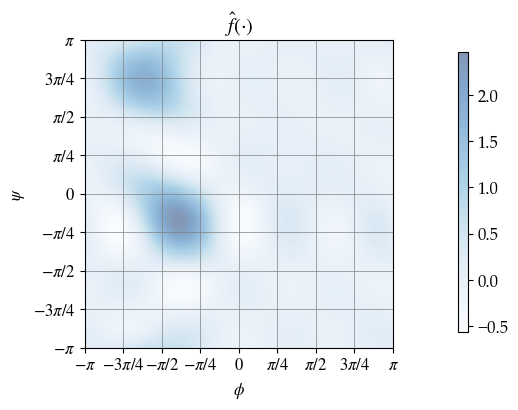

In [9]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111)

im = ax.pcolormesh(
    x_phi_,
    x_psi_,
    hat_f,
    alpha=0.5,
    shading='auto',
    cmap='Blues'
)

ax.grid(True, color='gray', lw=0.5)
cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(im, orientation='vertical', cax=cbar_ax)
ax.set_title('$\\log \\;\\hat{f}$')

ax.axis('square')
ax.set_title('$\\hat{f}(\cdot)$')

radian_ticks = [i * np.pi/4 for i in range(-4,5)]
radian_ticklabels = ['$-\\pi$', '$-3\\pi/4$', '$-\\pi/2$', '$-\\pi/4$', '$0$',
                    '$\\pi/4$', '$\\pi/2$', '$3\\pi/4$', '$\\pi$']

ax.set_xticks(radian_ticks)
ax.set_yticks(radian_ticks)
ax.set_yticklabels(radian_ticklabels)
ax.set_xticklabels(radian_ticklabels)
ax.set_xlabel('$\\phi$')
ax.set_ylabel('$\\psi$')

ax.set_xlim([-np.pi, np.pi])
ax.set_ylim([-np.pi, np.pi])

## Empirical Bayes denoising

In [12]:
def denoiser(x_phi, x_psi, K, rho):
    
    # estimate f
    hat_f = density_estimate(x_phi, x_psi, K)
    
    # estimate grad f
    hat_grad_f_phi = np.zeros(shape=x_phi.shape,dtype='complex128')
    hat_grad_f_psi = np.zeros(shape=x_psi.shape,dtype='complex128')
    for k_phi in range(-K,K+1):
        for k_psi in range(-K,K+1):
            for i in range(X.shape[0]):
                hat_grad_f_phi += 1j*k_phi*np.exp(1j*(k_phi*(x_phi - X_phi[i]) + k_psi*(x_psi - X_psi[i])))
                hat_grad_f_psi += 1j*k_psi*np.exp(1j*(k_phi*(x_phi - X_phi[i]) + k_psi*(x_psi - X_psi[i])))
    hat_grad_f_phi = np.real(hat_grad_f_phi)/(2*np.pi * X.shape[0])
    hat_grad_f_psi = np.real(hat_grad_f_psi)/(2*np.pi * X.shape[0])
                
                    
    # compute score function
    hat_score_phi = hat_grad_f_phi / np.maximum(hat_f, rho)
    hat_score_psi = hat_grad_f_psi / np.maximum(hat_f, rho)

    # compute denoiser
    delta_phi = np.zeros_like(x_phi)
    delta_psi = np.zeros_like(x_psi)

    for j in range(x_phi.shape[0]):
        delta_phi[j] = X_phi[j] + sigma2 * hat_score_phi[j]
        delta_psi[j] = X_psi[j] + sigma2 * hat_score_psi[j]
    
    delta = np.asarray([[np.cos(delta_phi),np.sin(delta_phi)],
                        [np.cos(delta_psi),np.sin(delta_psi)]]).T
    
    return delta

In [13]:
rho = 0.1
delta = denoiser(X_phi, X_psi, K, rho)

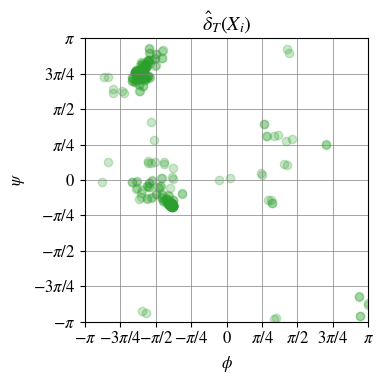

In [14]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111)

delta_phi = circle.extrinsic_to_intrinsic_coords(delta[:,:,0])
delta_psi = circle.extrinsic_to_intrinsic_coords(delta[:,:,1])
plt.scatter(delta_phi, delta_psi, color='C2', alpha=0.25)
ax.grid(True, color='gray', lw=0.5)
ax.axis('square')
ax.set_title('$\\hat{\\delta}_T(X_i)$')

radian_ticks = [i * np.pi/4 for i in range(-4,5)]
radian_ticklabels = ['$-\\pi$', '$-3\\pi/4$', '$-\\pi/2$', '$-\\pi/4$', '$0$',
                    '$\\pi/4$', '$\\pi/2$', '$3\\pi/4$', '$\\pi$']

ax.set_xticks(radian_ticks)
ax.set_yticks(radian_ticks)
ax.set_yticklabels(radian_ticklabels)
ax.set_xticklabels(radian_ticklabels)
ax.set_xlabel('$\\phi$')
ax.set_ylabel('$\\psi$')

ax.set_xlim([-np.pi, np.pi])
ax.set_ylim([-np.pi, np.pi])

plt.tight_layout()

## Plotting

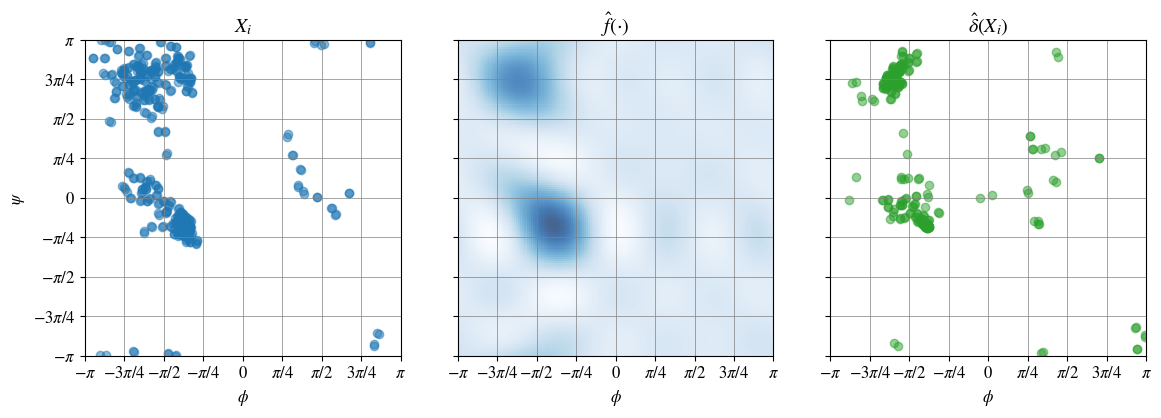

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(12,4), sharex=True, sharey=True)


radian_ticks = [i * np.pi/4 for i in range(-4,5)]
radian_ticklabels = ['$-\\pi$', '$-3\\pi/4$', '$-\\pi/2$', '$-\\pi/4$', '$0$',
                    '$\\pi/4$', '$\\pi/2$', '$3\\pi/4$', '$\\pi$']

for m in range(3):
    ax[m].grid(True, color='gray', lw=0.5)
    ax[m].axis('square')
    
    ax[m].set_xticks(radian_ticks)
    ax[m].set_yticks(radian_ticks)
    ax[m].set_yticklabels(radian_ticklabels)
    ax[m].set_xticklabels(radian_ticklabels)
    ax[m].set_xlabel('$\\phi$')

    ax[m].set_xlim([-np.pi, np.pi])
    ax[m].set_ylim([-np.pi, np.pi])

ax[0].scatter(X_phi, X_psi, color='C0', alpha=0.5)
ax[0].set_ylabel('$\\psi$')
ax[0].set_title('$X_i$')

im = ax[1].pcolormesh(x_phi_, x_psi_, hat_f, alpha=0.75, shading='auto', cmap='Blues')
ax[1].grid(True, color='gray', lw=0.5)
# cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
# fig.colorbar(im, orientation='vertical', cax=cbar_ax)
ax[1].set_title('$\\hat{f}(\\cdot)$')


ax[2].scatter(delta_phi, delta_psi, color='C2', alpha=0.5)
ax[2].set_title('$\\hat{\\delta}(X_i)$')

plt.tight_layout()

plt.savefig('chemi.pdf')